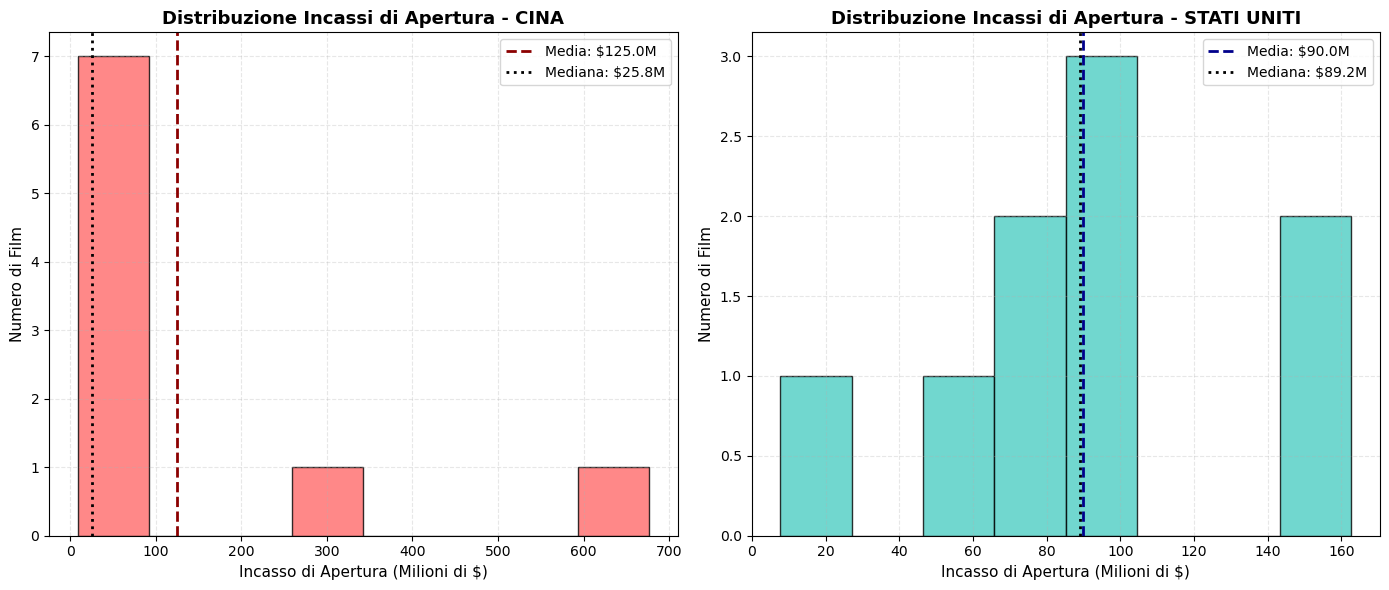

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carica i dati
df = pd.read_csv('opening - Foglio1 (1).csv')

# Prepara i dati per gli istogrammi
df_hist = df.copy()

# Funzione per convertire i valori in formato numerico
def convert_to_numeric(value):
    if pd.isna(value) or value == '-' or value == '':
        return np.nan
    # Rimuovi $ e virgole, converti in float
    value_str = str(value).replace('$', '').replace(',', '')
    try:
        return float(value_str)
    except:
        return np.nan

# Applica la conversione
df_hist['China_numeric'] = df_hist['China'].apply(convert_to_numeric)
df_hist['America_numeric'] = df_hist['America'].apply(convert_to_numeric)

# Rimuovi i film che non hanno dati per entrambi i paesi
df_hist_clean = df_hist.dropna(subset=['China_numeric', 'America_numeric']).copy()

# ISTOGRAMMI SEPARATI PER CONFRONTO
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Configurazione per entrambi gli istogrammi
bins = 8
colors = ['#FF6B6B', '#4ECDC4']

# Istogramma per la Cina
axes[0].hist(df_hist_clean['China_numeric'] / 1e6, bins=bins, color=colors[0], 
             edgecolor='black', alpha=0.8)
axes[0].axvline(df_hist_clean['China_numeric'].mean() / 1e6, color='darkred', 
                linestyle='--', linewidth=2, label=f'Media: ${df_hist_clean["China_numeric"].mean()/1e6:.1f}M')
axes[0].axvline(df_hist_clean['China_numeric'].median() / 1e6, color='black', 
                linestyle=':', linewidth=2, label=f'Mediana: ${df_hist_clean["China_numeric"].median()/1e6:.1f}M')

axes[0].set_xlabel('Incasso di Apertura (Milioni di $)', fontsize=11)
axes[0].set_ylabel('Numero di Film', fontsize=11)
axes[0].set_title('Distribuzione Incassi di Apertura - CINA', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].tick_params(axis='x', rotation=0)

# Istogramma per gli Stati Uniti
axes[1].hist(df_hist_clean['America_numeric'] / 1e6, bins=bins, color=colors[1], 
             edgecolor='black', alpha=0.8)
axes[1].axvline(df_hist_clean['America_numeric'].mean() / 1e6, color='darkblue', 
                linestyle='--', linewidth=2, label=f'Media: ${df_hist_clean["America_numeric"].mean()/1e6:.1f}M')
axes[1].axvline(df_hist_clean['America_numeric'].median() / 1e6, color='black', 
                linestyle=':', linewidth=2, label=f'Mediana: ${df_hist_clean["America_numeric"].median()/1e6:.1f}M')

axes[1].set_xlabel('Incasso di Apertura (Milioni di $)', fontsize=11)
axes[1].set_ylabel('Numero di Film', fontsize=11)
axes[1].set_title('Distribuzione Incassi di Apertura - STATI UNITI', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()